### Set Up

In [1]:
import torch
import torch.nn as nn
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from torch.utils.data import TensorDataset, DataLoader
import time

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load Dataset

In [3]:
def load_housing_data():
    tarball_path = Path("../chapter10/datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("../chapter10/datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="../chapter10/datasets", filter="data")
    return pd.read_csv(Path("../chapter10/datasets/housing/housing.csv"))

In [4]:
housing_full = load_housing_data()

In [5]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Data Processing

In [6]:
housing_full = housing_full.drop("ocean_proximity", axis=1)

In [7]:
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_full)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','median_house_value']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[ -118.49, 34.26, 29. ,..., 409. , 3.53,179700. ]"


In [8]:
X = imputer.transform(housing_full)
housing_full = pd.DataFrame(X, columns=housing_full.columns, index=housing_full.index)

In [9]:
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)
train_set, val_set = train_test_split(train_set, test_size=0.2, random_state=42)
housing_full.shape, train_set.shape, val_set.shape, test_set.shape

((20640, 9), (13209, 9), (3303, 9), (4128, 9))

In [10]:
X_train, y_train = train_set.drop("median_house_value", axis=1), train_set["median_house_value"]
X_valid, y_valid = val_set.drop("median_house_value", axis=1), val_set["median_house_value"]
X_test, y_test = test_set.drop("median_house_value", axis=1), test_set["median_house_value"]

In [11]:
X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float64, device=device)
X_valid = torch.tensor(X_valid.to_numpy(), dtype=torch.float64, device=device)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float64, device=device)

In [12]:
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_valid = torch.tensor(y_valid.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)

In [13]:
X_train

tensor([[-1.2129e+02,  3.8710e+01,  3.2000e+01,  ...,  1.0270e+03,
          3.4300e+02,  3.5769e+00],
        [-1.2138e+02,  3.8640e+01,  1.9000e+01,  ...,  2.2560e+03,
          9.2600e+02,  2.1472e+00],
        [-1.2129e+02,  3.8900e+01,  4.5000e+01,  ...,  1.1040e+03,
          4.0700e+02,  3.1691e+00],
        ...,
        [-1.1714e+02,  3.2710e+01,  4.3000e+01,  ...,  8.5700e+02,
          2.0800e+02,  1.2841e+00],
        [-1.2226e+02,  3.7880e+01,  5.2000e+01,  ...,  1.7980e+03,
          7.6900e+02,  1.7250e+00],
        [-1.1750e+02,  3.4660e+01,  2.0000e+01,  ...,  4.8600e+02,
          1.9600e+02,  2.0184e+00]], device='cuda:0', dtype=torch.float64)

In [14]:
y_train

tensor([[103800.],
        [143400.],
        [108700.],
        ...,
        [ 72000.],
        [287500.],
        [ 84900.]], device='cuda:0', dtype=torch.float64)

In [15]:
X_train.device, y_train.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [16]:
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train- means) / stds
X_valid = (X_valid- means) / stds
X_test = (X_test- means) / stds

In [17]:
X_train

tensor([[-0.8667,  1.4490,  0.2663,  ..., -0.3487, -0.4120, -0.1475],
        [-0.9118,  1.4161, -0.7652,  ...,  0.7295,  1.1263, -0.8947],
        [-0.8667,  1.5382,  1.2979,  ..., -0.2811, -0.2431, -0.3606],
        ...,
        [ 1.2113, -1.3684,  1.1392,  ..., -0.4978, -0.7682, -1.3459],
        [-1.3525,  1.0592,  1.8533,  ...,  0.3277,  0.7121, -1.1154],
        [ 1.0311, -0.4528, -0.6859,  ..., -0.8233, -0.7998, -0.9621]],
       device='cuda:0', dtype=torch.float64)

In [18]:
ymeans = y_train.mean(dim=0, keepdims=True)
ystds = y_train.std(dim=0, keepdims=True)
y_train = (y_train- ymeans) / ystds
y_valid = (y_valid- ymeans) / ystds
y_test = (y_test- ymeans) / ystds

In [19]:
train_dataset = TensorDataset(X_train, y_train)
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=8, prefetch_factor=16)

### Cross Val

In [20]:
def train(model, optimizer, criterion, train_loader, X_val, y_val, n_epochs):
    model.train()
    losses = []
    val_losses = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        #print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}")
    return losses, val_losses

In [21]:
def batch_size_validation(batches):
    num_workers=8
    prefetch_factor=16
    learning_rate = 0.1
    n_epochs = 10
    n_features = X_train.shape[1]
    train_dataset = TensorDataset(X_train, y_train)
    times = []
    losses = []
    for batch_size in batches:
        model = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1))
        model.to(device=device, dtype=torch.float64)
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
        mse = nn.MSELoss()
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=num_workers, prefetch_factor=prefetch_factor)
        start = time.time()
        train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)
        end = time.time()
        times.append(end-start)
        losses.append(val_loss[-1])
        print(f"Batch {batch_size} Done")
    plt.plot(times, batches)
    plt.show()
    plt.plot(losses, batches)
    plt.show()
    return times, losses

Batch 13209 Done
Batch 8192 Done
Batch 4096 Done
Batch 2048 Done
Batch 1024 Done
Batch 512 Done
Batch 256 Done


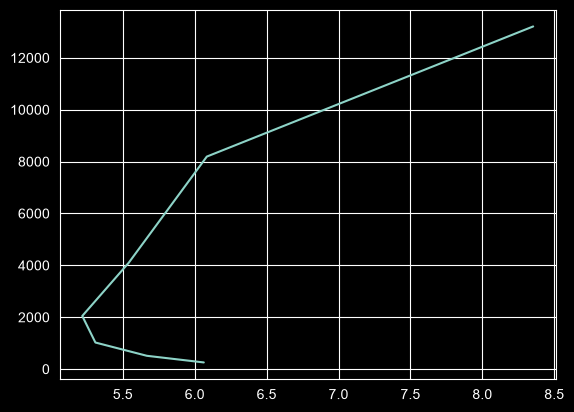

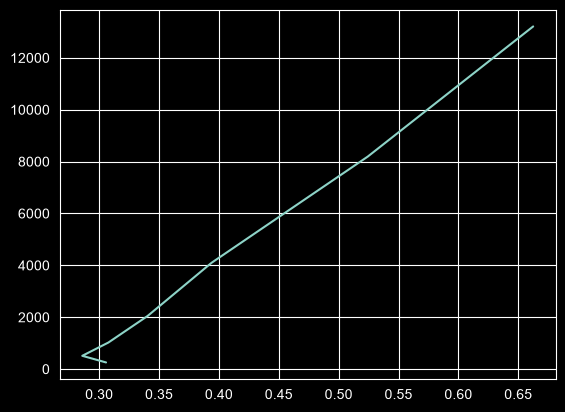

([8.353192806243896,
  6.083818197250366,
  5.540452241897583,
  5.217832803726196,
  5.309178590774536,
  5.667174339294434,
  6.062899589538574],
 [0.6624452238955835,
  0.5242795932543468,
  0.3937779694382619,
  0.34042277991312936,
  0.3076814621967285,
  0.2858502523480989,
  0.30571399691717177])

In [22]:
batch_size_validation([256, 512, 1024, 2048, 4096, 8192, 13209][::-1])

worker 12 Done
worker 10 Done
worker 8 Done
worker 6 Done
worker 4 Done
worker 2 Done


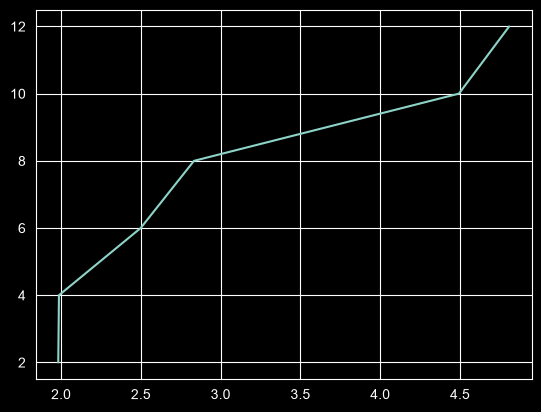

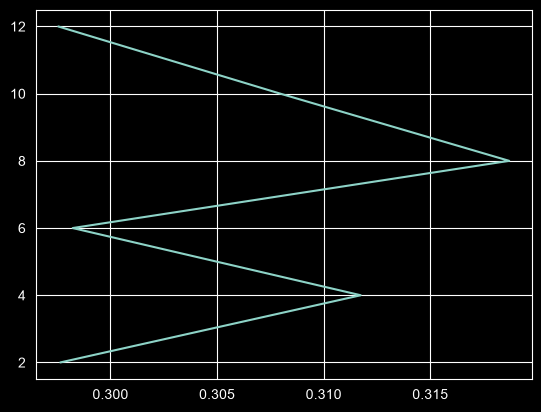

([4.808087348937988,
  4.493204116821289,
  2.8328278064727783,
  2.4987740516662598,
  1.9865479469299316,
  1.9822826385498047],
 [0.29755150965380145,
  0.3079617007700436,
  0.31869824268203956,
  0.2982280844030112,
  0.3117358633633465,
  0.2976481589911401])

In [23]:
def workers_validation(num_workers_list):
    prefetch_factor=16
    learning_rate = 0.1
    n_epochs = 10
    batch_size = 1024
    n_features = X_train.shape[1]
    train_dataset = TensorDataset(X_train, y_train)
    times = []
    losses = []
    for num_workers in num_workers_list:
        model = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1))
        model.to(device=device, dtype=torch.float64)
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
        mse = nn.MSELoss()
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=num_workers, prefetch_factor=prefetch_factor)
        start = time.time()
        train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)
        end = time.time()
        times.append(end-start)
        losses.append(val_loss[-1])
        print(f"worker {num_workers} Done")
    plt.plot(times, num_workers_list)
    plt.show()
    plt.plot(losses, num_workers_list)
    plt.show()
    return times, losses

workers_validation([2, 4, 6, 8, 10, 12][::-1])

factor 30 Done
factor 28 Done
factor 26 Done
factor 24 Done
factor 22 Done
factor 20 Done
factor 18 Done
factor 16 Done
factor 14 Done
factor 12 Done
factor 10 Done
factor 8 Done
factor 6 Done
factor 4 Done
factor 2 Done


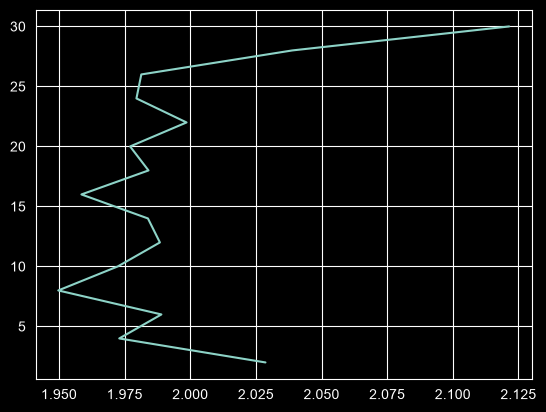

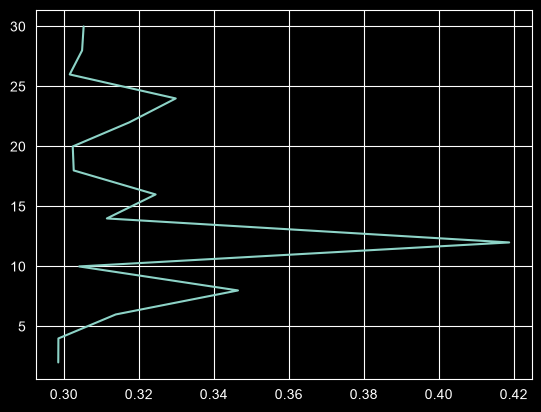

([2.1214828491210938,
  2.0388450622558594,
  1.9813592433929443,
  1.9795050621032715,
  1.998591423034668,
  1.9770944118499756,
  1.9840953350067139,
  1.9585521221160889,
  1.9838876724243164,
  1.9884400367736816,
  1.9723854064941406,
  1.9497311115264893,
  1.9890141487121582,
  1.9729597568511963,
  2.0286567211151123],
 [0.3052912021780657,
  0.3048797747243785,
  0.3015769515194106,
  0.3298578993838898,
  0.3174299964727821,
  0.30238833307702984,
  0.30264719556131564,
  0.32448935568437537,
  0.31148246195080376,
  0.4188034297509194,
  0.3040992258750373,
  0.3464656827334102,
  0.31385886139234875,
  0.29856045528962405,
  0.2985250634157111])

In [22]:
def prefetch_factor_validation(prefetch_factor_list):
    num_workers=4
    learning_rate = 0.1
    n_epochs = 10
    batch_size = 1024
    n_features = X_train.shape[1]
    train_dataset = TensorDataset(X_train, y_train)
    times = []
    losses = []
    for prefetch_factor in prefetch_factor_list:
        model = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1))
        model.to(device=device, dtype=torch.float64)
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
        mse = nn.MSELoss()
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=num_workers, prefetch_factor=prefetch_factor)
        start = time.time()
        train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)
        end = time.time()
        times.append(end-start)
        losses.append(val_loss[-1])
        print(f"factor {prefetch_factor} Done")
    plt.plot(times, prefetch_factor_list)
    plt.show()
    plt.plot(losses, prefetch_factor_list)
    plt.show()
    return times, losses

prefetch_factor_validation(list(range(2, 31, 2))[::-1])

In [22]:
def fit():
    num_workers=4
    learning_rate = 0.1
    n_epochs = 10
    batch_size = 1024
    n_features = X_train.shape[1]
    train_dataset = TensorDataset(X_train, y_train)
    prefetch_factor = 10
    model = nn.Sequential(nn.Linear(n_features, 50), nn.ReLU(), nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1))
    model.to(device=device, dtype=torch.float64)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    mse = nn.MSELoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=True, num_workers=num_workers, prefetch_factor=prefetch_factor)
    start = time.time()
    train_loss, val_loss = train(model, optimizer, mse, train_loader, X_valid, y_valid, n_epochs)
    end = time.time()
    print(end-start)
    print(val_loss)
    #Takes 2 sec 

fit()

1.9639689922332764
[0.5328869243742379, 0.3919923317682253, 0.36181880192744575, 0.3582033487336476, 0.3291667827580481, 0.3342306588449943, 0.4186975971465868, 0.3193421629955914, 0.30125565635169865, 0.29951684566846903]
